In [98]:
import numpy as np
from numpy import linalg as line
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import sympy as sp
import  numpy.linalg as line
from scipy.sparse import coo_matrix

Exercice 1

In [99]:
#question 1

In [100]:
def generateMesh(N):
    x   = np.linspace(0, 2*np.pi, N)
    y   = np.linspace(0, 2*np.pi, N)
    Vtx = [(xi, yi) for yi in y for xi in x]
    Elt = []
    for i in range(N-1):
        for j in range(N-1):                # Quadrilatères à diviser en triangles
            Elt.append([i*N + j, ((i+1)*N) + j + 1, ((i+1)*N) + j])
            Elt.append([i*N + j, i*N + j+1, ((i+1)*N) + j + 1])
    return (Elt,Vtx)

In [101]:
def Filtre_(elt,vtx):
    vtx_in        = []
    vtx_out       = []
    indicevtx_out = []
    indicevtx_in  = []
    elt_in        = []
    
    #On filtre les noeuds qui seront conservés en étudiant leurs coordonées
    for i in range(0,len(vtx)):
        if (vtx[i][0] > np.pi/2 and vtx[i][0] < 3*np.pi/2) and (vtx[i][1] < 3*np.pi/2 and vtx[i][1] > np.pi/2):
            vtx_out.append(vtx[i])
            indicevtx_out.append(i)
        else:
            vtx_in.append(vtx[i])
            indicevtx_in.append(i)
    
    #print(indicevtx_in)
    #print(vtx_in)
    
    #On filtre les triangles qui seront conservés en étudiant les coordonées de leurs barycentres et les milieux de leurs cotés.
    for e in elt:
        t = 0
        k = 0
        
        milieu_1 = [ (vtx[e[1]][0] + vtx[e[0]][0] )/2 , (vtx[e[1]][1] + vtx[e[0]][1] )/2 ]
        milieu_2 = [ (vtx[e[1]][0] + vtx[e[2]][0] )/2 , (vtx[e[1]][1] + vtx[e[2]][1] )/2 ]
        milieu_3 = [ (vtx[e[2]][0] + vtx[e[0]][0] )/2 , (vtx[e[2]][1] + vtx[e[0]][1] )/2 ]
        
        if (milieu_1[0] > np.pi/2 and milieu_1[0] < 3*np.pi/2) and (milieu_1[1] < 3*np.pi/2 and milieu_1[1] > np.pi/2):
            t = 1
        if (milieu_2[0] > np.pi/2 and milieu_2[0] < 3*np.pi/2) and (milieu_2[1] < 3*np.pi/2 and milieu_2[1] > np.pi/2):
            t = 1
        if (milieu_3[0] > np.pi/2 and milieu_3[0] < 3*np.pi/2) and (milieu_3[1] < 3*np.pi/2 and milieu_3[1] > np.pi/2):
            t = 1
        
        
        pts = [vtx[e[0]],vtx[e[1]],vtx[e[2]]]
        #print([pts[0][0],pts[1][0],pts[2][0]])
        xc = np.mean([pts[0][0],pts[1][0],pts[2][0]])
        #print(xc)
        yc = np.mean([pts[0][1],pts[1][1],pts[2][1]])
        if np.pi/2 < xc < 3*np.pi/2 and np.pi/2 < yc < 3*np.pi/2:
              t = 1
        
        elt = np.array(elt)
        
        
        
        
        
        
        for i in range(0,3):
            if (vtx[e[i]] not in vtx_in) or (t == 1 ):
                k=1
        
        #les triangles conservés sont ceux pour lesquels k==0
        #parmis les triangles conservés on réorganise leur numérotation
        if k==0:
            #elt_in.append(e)
            
            l = []
            for i in range(0,3):
                for j in range(0,len(vtx_in)):
                    if vtx[e[i]] == vtx_in[j]:
                        l.append(j)
            elt_in.append(l)
           
    return (elt_in,vtx_in)



In [102]:
Maillage_test = generateMesh(9)
Maillage_Filtre_test = Filtre_(Maillage_test[0],Maillage_test[1])
#print(Maillage_Filtre_test)

In [103]:
#question 2

In [104]:
def PlotMesh(vtx,elt):
    
    x      = [vtx[i][0] for i in range(len(vtx))]
    y      = [vtx[i][1] for i in range(len(vtx))]
    for i in range (0,len(elt)):
        i1 = elt[i][0]
        i2 = elt[i][1]
        i3 = elt[i][2]
        plt.triplot((vtx[i1][0],vtx[i2][0],vtx[i3][0]),(vtx[i1][1],vtx[i2][1],vtx[i3][1]))
        
    triang = tri.Triangulation(x, y, elt)
    return(triang)

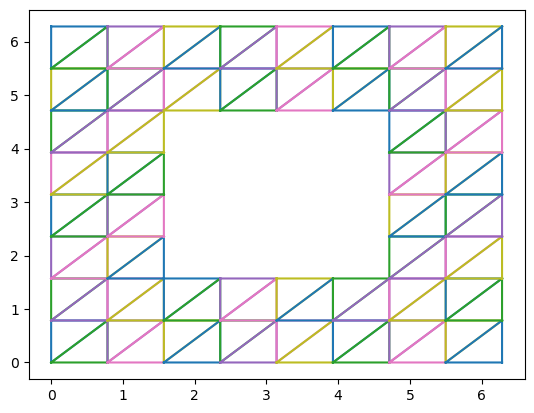

In [105]:
PlotMesh(Maillage_Filtre_test[1],Maillage_Filtre_test[0])

In [10]:
#question3

In [14]:
def PlotMesh_normal(vtx,elt):
    
    x = [vtx[i][0] for i in range(len(vtx))]
    y = [vtx[i][1] for i in range(len(vtx))]
    for i in range (0,len(elt)):
        i1 = elt[i][0]
        i2 = elt[i][1]
        i3 = elt[i][2]
        plt.triplot((vtx[i1][0],vtx[i2][0],vtx[i3][0]),(vtx[i1][1],vtx[i2][1],vtx[i3][1]))
        
    triang = tri.Triangulation(x, y, elt)
    #on a tracé le maillage comme précedemment

    
    
    M = 0
    compt=0
    i = 0
    while compt != 1:
        compt = 0
        for e in elt:
            if i in e:
                compt = compt+1
        M = M + 1
        i = i +1
    
    
    
    
    #on etudie chaque noeuds
    for i in range(0,len(vtx)):
        compt = 0
        for e in elt:
            if i in e:
                compt = compt + 1
            
        #les points du bord ( hors coins) sont dans exactement 3 triangles    
        if compt == 3:
            k1 = 0
            k2 = 0
            k3 = 0
            k4 = 0
            for e in elt:
                #parmis ces vecteurs on étudie les 4 possibilités différentes pour savoir qui est le vecteur normal  
                if (i in e) and (i+1 not in e):
                    k1 = k1 + 1
                if (i in e) and (i-1 not in e):
                    k2 = k2 + 1
                if (i in e) and (i-M in e):
                    k3 = k3 + 1
                if (i in e) and (i+M in e):
                    k4 = k4 + 1

            if k1 == 3 :
                plt.quiver(vtx[i][0],vtx[i][1],1,0)
            if k2 == 3 :
                plt.quiver(vtx[i][0],vtx[i][1],-1,0)
            if k3 == 0 and k1 != 3 and k2 != 3 :
                plt.quiver(vtx[i][0],vtx[i][1],0,-1)
            if k4 == 0 and k1 != 3 and k2 != 3 :
                plt.quiver(vtx[i][0],vtx[i][1],0,1)
    
    return(triang)

In [ ]:
#on aurait pu utiliser la fonction Boundary de la suite du TP pour avoir directement les points du bord.

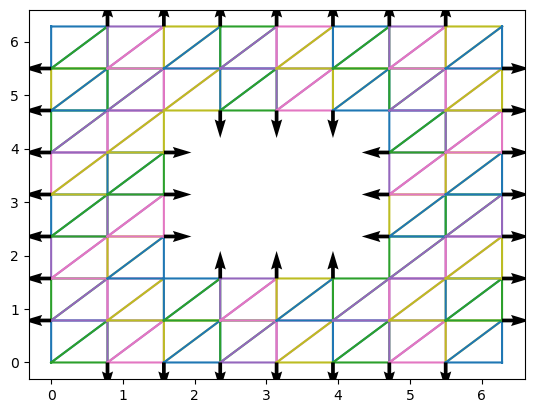

In [106]:
PlotMesh_normal(Maillage_Filtre_test[1],Maillage_Filtre_test[0])

Exercice 2

In [16]:
#question 1

La formulation variationelle est :

$$
a(u, v) = \int_{\Omega} \nabla u \cdot \nabla v dx + \mu \int_{\Omega} u v \, dx = \int_{\Omega} f v \, dx + \int_{\Gamma_N} \partial_n u_{\text{ex}} \cdot v \, ds = l(v)
$$

In [17]:
#qustion 2

In [109]:
def Mloc(vtx,e):
    if len(e) == 3 :
    
        coord_a_x = vtx[e[0]][0]
        coord_a_y = vtx[e[0]][1]
        coord_b_x = vtx[e[1]][0]
        coord_b_y = vtx[e[1]][1]
        coord_c_x = vtx[e[2]][0]
        coord_c_y = vtx[e[2]][1]
        long_ab   = np.sqrt( (coord_b_x - coord_a_x)**2 + (coord_b_y - coord_a_y)**2)
        long_ac   = np.sqrt( (coord_c_x - coord_a_x)**2 + (coord_c_y - coord_a_y)**2)
        long_bc   = np.sqrt( (coord_b_x - coord_c_x)**2 + (coord_b_y - coord_c_y)**2)

        
        #print(aire)
        AB        = [coord_b_x-coord_a_x,coord_b_y-coord_a_y]
        AC        = [coord_c_x-coord_a_x,coord_c_y-coord_a_y]
        aire      = np.abs(AB[0]*AC[1] - AB[1]*AC[0])/2
        m         = np.array([[2,1,1],[1,2,1],[1,1,2]])
        
        
        
        return  m*aire/12 
    
   
    
    
    

In [113]:
#Maillage de test
vtx1 = [[0. , 0. ],[0.5, 0. ],[1. , 0. ],[0. , 0.5],[0.5, 0.5],[1. , 0.5],[0. , 1. ],[0.5 ,1. ],[1.,  1. ]]
elt1 = [[0 ,1, 4],[0, 4, 3],[1, 2, 5],[1, 5, 4],[3, 4, 7],[3, 7, 6],[4, 5, 8],[4, 8, 7]]
vtx2 = [[0, 0], [1, 0], [0, 1],[1,1]]
elt2 = [[0, 1, 2],[0,3,2]]
vtx7 = [[0, 0], [1, 0], [1, 1], [0, 1]]
elt7 = [[0, 1, 2], [0, 2, 3]]
vtx5 =[[0,0],[0,1],[1,0]]
e1 = [0,1,2]
e2 = [0,1]

In [114]:
#Mloc(vtx5,e1)
#Mloc(Maillage_Filtre_test[1],Maillage_Filtre_test[0][1])
#Mloc(vtx7,elt7[0])

In [24]:
def Mass(vtx,elt):
    
    ligne   = []
    colonne = []
    valeur  = []
     

    for e in elt:
        mloc = Mloc(vtx,e)            
        for i in range(0,3):
            for j in range(0,3):
                ligne.append(e[i])
                colonne.append(e[j])
                valeur.append(mloc[i][j])
    
                
            
            
    n = len(vtx)
    M = coo_matrix((valeur, (ligne, colonne)), shape=(n, n))
    return M  #.todense() pour pas avoir les repetitions.

In [118]:
def in_Omega_top(vtx,e):
    return np.min([vtx[e[i]][1] for i in range(3)]) >= np.pi
#fonction pour determiner si un point est dans la partie supérieur du maillage afin d'appliquer mu



def Mass_top(vtx, elt):
    ligne   = []
    colonne = []
    valeur  = []
     
    for e in elt:
        if in_Omega_top(vtx,e) :
            mloc = Mloc(vtx,e)            
            for i in range(0,3):
                for j in range(0,3):
                    ligne.append(e[i])
                    colonne.append(e[j])
                    valeur.append(mloc[i][j])
    

                
            
            
    n = len(vtx)
    M = coo_matrix((valeur, (ligne, colonne)), shape=(n, n))
    return M  #.todense() pour pas avoir les repetitions.

In [134]:
Mass(vtx1,elt1).toarray()
#Mass_top(vtx1,elt1).toarray()

array([[0.04166667, 0.01041667, 0.        , 0.01041667, 0.02083333,
        0.        , 0.        , 0.        , 0.        ],
       [0.01041667, 0.0625    , 0.01041667, 0.        , 0.02083333,
        0.02083333, 0.        , 0.        , 0.        ],
       [0.        , 0.01041667, 0.02083333, 0.        , 0.        ,
        0.01041667, 0.        , 0.        , 0.        ],
       [0.01041667, 0.        , 0.        , 0.0625    , 0.02083333,
        0.        , 0.01041667, 0.02083333, 0.        ],
       [0.02083333, 0.02083333, 0.        , 0.02083333, 0.125     ,
        0.02083333, 0.        , 0.02083333, 0.02083333],
       [0.        , 0.02083333, 0.01041667, 0.        , 0.02083333,
        0.0625    , 0.        , 0.        , 0.01041667],
       [0.        , 0.        , 0.        , 0.01041667, 0.        ,
        0.        , 0.02083333, 0.01041667, 0.        ],
       [0.        , 0.        , 0.        , 0.02083333, 0.02083333,
        0.        , 0.01041667, 0.0625    , 0.01041667],


In [131]:
def Kloc(vtx, e):
    coord_a_x = vtx[e[0]][0]
    coord_a_y = vtx[e[0]][1]
    coord_b_x = vtx[e[1]][0]
    coord_b_y = vtx[e[1]][1]
    coord_c_x = vtx[e[2]][0]
    coord_c_y = vtx[e[2]][1]
    AB        = [coord_b_x-coord_a_x,coord_b_y-coord_a_y]
    AC        = [coord_c_x-coord_a_x,coord_c_y-coord_a_y]
    BC        = [coord_c_x-coord_b_x,coord_c_y-coord_b_y]
    aire      = np.abs(AB[0]*AC[1] - AB[1]*AC[0])/2 
    #print(aire)
    B = np.array([[coord_c_x-coord_b_x,coord_a_x-coord_c_x,coord_b_x-coord_a_x],[coord_c_y-coord_b_y,coord_a_y-coord_c_y,coord_b_y-coord_a_y]])
    #print(B)
    return B.T @ B /(4*aire)

In [132]:
def Rig(vtx,elt):
    ligne   = []
    colonne = []
    valeur  = []
     
    if len(elt[0]) == 3:
        for e in elt:         
            kloc = Kloc(vtx,e)
            for i in range(0,3):
                for j in range(0,3):
                    ligne.append(e[i])
                    colonne.append(e[j])
                    valeur.append(kloc[i][j])

                
            
            
    n = len(vtx)
    M = coo_matrix((valeur, (ligne, colonne)), shape=(n, n))
    return M  #.todense() pour pas avoir les repitions.

In [133]:
Maillage_test        = generateMesh(5)
Maillage_Filtre_test = Filtre_(Maillage_test[0],Maillage_test[1])
Kloc(Maillage_Filtre_test[1],Maillage_Filtre_test[0][7]) 
#print(Maillage_Filtre_test[0][0])

array([[ 0.5, -0.5,  0. ],
       [-0.5,  1. , -0.5],
       [ 0. , -0.5,  0.5]])

In [128]:
Kloc(vtx2,elt2[0])
Kloc(vtx2,elt2[1])
K2 = Kloc(vtx1, elt1[0])
#print(K2)
K = Rig(vtx2, elt2)
#print(K)
M = Mass(vtx2, elt2)
#print(M)

In [129]:
Rig(vtx2,elt2).toarray() 

array([[ 1.5, -0.5, -1. ,  0. ],
       [-0.5,  0.5,  0. ,  0. ],
       [-1. ,  0. ,  1.5, -0.5],
       [ 0. ,  0. , -0.5,  0.5]])

In [135]:
#question 3

In [136]:
def A(vtx,elt):
    return (Rig(vtx,elt) + Mass(vtx,elt)+Mass_sparse_r(vtx, elt))

In [137]:
A(Maillage_Filtre_test[1],Maillage_Filtre_test[0]).toarray()

array([[ 1.41123352, -0.39719162,  0.        ,  0.        ,  0.        ,
        -0.39719162,  0.20561676,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [-0.39719162,  2.61685028, -0.39719162,  0.        ,  0.        ,
         0.        , -0.79438324,  0.20561676,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.39719162,  2.61685028, -0.39719162,  0.        ,
         0.        ,  0.        , -0.79438324,  0.20561676,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
  

In [138]:
#A(vtx1,elt1).toarray()

In [140]:
#fonction pour calculer le gradient en (x,y)
def grad_uex(x, y, p, q):
    return np.array([2 * p * np.cos(2 * p * x) * np.sin(2 * q * y),2 * q * np.sin(2 * p * x) * np.cos(2 * q * y)])

#produit vectoriel entre le gradient en (x,y) et le vecteur normal associé au point (x,y)
def deriv_normal(x, y, normal_vec, p, q):
    grad = grad_uex(x, y, p, q)
    return np.dot(grad, normal_vec)

#renvoie les vecteurs normaux associés au bord du maillage
def List_Vect_Norm(vtx, elt):
 
    e1 = np.array([1,0])
    e2 = np.array([0,1])
    mat = np.zeros((len(elt),2))
    
    for i in range(len(elt)):
        bord = elt[i]
        x0, y0 = vtx[bord[0]][0], vtx[bord[0]][1]
        x1, y1 = vtx[bord[1]][0], vtx[bord[1]][1]
        #print(bord[0],bord[1])
        #print(x1,x0)
        if x1==x0:
            
            if x1 == 0 or x1 == 2*np.pi:
                mat[i] = e1*(-1)**((x1==0))
            if x1 < np.pi and x1 != 0:
                mat[i]  = 0
            if x1 > np.pi and x1 != 2*np.pi:
                mat[i] = 0
            #les deux derniers if permettent d'avoir des vecteurs nuls sur le bord interieur omegaD
            #cela permet d'avoir l'integrale sur le bord en ces points = 0
        else :
            if y1 == 0 or y1 == 2*np.pi: 
                mat[i] = e2*(-1)**((y1==0))
            if y1 < np.pi and y1 != 0:
                mat[i]  = 0
            if y1 > np.pi and y1 != 2*np.pi:
                mat[i] = 0
            #les deux derniers if permettent d'avoir des vecteurs nuls sur le bord interieur omegaD
            #cela permet d'avoir l'integrale sur le bord en ces points = 0    
        #print(mat[i])
    return mat



#renvoie le bord du maillage
def Boundary(elt):
    b = []
    for i in range(0,len(elt)):
        tr = elt[i]
        for j in range(0,3):
            f = []
            for k in range(0,3):
                if k != j:
                    f.append(tr[k])
                    f.sort()
            if f in b :
                b.remove(f)
            else :
                b.append(f)
    return b





In [225]:
#test des fonctions intermediaires
#grad_uex(0.7853981633974483,0.0,1,2)
#Boundary(Maillage_Filtre_test[0])

In [226]:
#on approche l'integrale de bors en la calculant en tout les milieux des segments de bord 
def Approx_Integrale_bord(vtx, elt, p,q):
    n = len(vtx)
    bord = Boundary(elt)
    b_neumann = np.zeros(n)
    vect_norm = List_Vect_Norm(vtx, bord)
    k = 0
    for (i, j) in bord:
        
        x1 = vtx[i][0]
        y1 = vtx[i][1]
        x2 = vtx[j][0]
        y2 = vtx[j][1]
        
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
        long = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        normal = vect_norm[k] 
        #print(normal)
        k = k+1
        #print(normal)
        g_val = deriv_normal(xm, ym,normal,p,q)  # Évalue ∂n u_ex au point milieu
        #print(g_val)
        contrib = g_val * long / 2

        b_neumann[i] += contrib
        b_neumann[j] += contrib
        
    return b_neumann.reshape(n,1)

In [227]:
#print(Boundary(Maillage_Filtre_test[0]))
Maillage_test = generateMesh(5)
Maillage_Filtre_test = Filtre_(Maillage_test[0],Maillage_test[1])
#print(Maillage_Filtre_test[0][0])
#print(List_Vect_Norm(Maillage_Filtre_test[1],Boundary(Maillage_Filtre_test[0])))

In [145]:
Approx_Integrale_bord(Maillage_Filtre_test[1],Maillage_Filtre_test[0],1,2)

array([[-3.14159265e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 3.14159265e+00],
       [-7.69468277e-16],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 7.69468277e-16],
       [-1.53893655e-15],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 1.53893655e-15],
       [-2.30840483e-15],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 2.30840483e-15],
       [ 3.14159265e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [-3.14159265e+00]])

In [146]:
#question 5

In [229]:
def Fh(vtx, elt, p, q):

    n = len(vtx)

    # Vecteur valeurs nodale
    F = np.array([(4 * (p**2 + q**2) + mu(x, y)) * np.sin(2 * p * x) * np.sin(2 * q * y) for (x, y) in vtx])
    
    
    M = Mass(vtx, elt)  
    #print(M.toarray())
    Fh = M @ F
    #print(vtx[-1])
    #print(F[-1])
    return Fh.reshape(n, 1)

In [153]:
Fh(Maillage_Filtre_test[1],Maillage_Filtre_test[0],1,2)

array([[-1.29517813e-31],
       [ 1.29517813e-31],
       [-1.29517813e-31],
       [ 1.29517813e-31],
       [ 2.59035626e-31],
       [-3.88553438e-31],
       [-5.18071251e-31],
       [ 5.18071251e-31],
       [-6.47589064e-31],
       [ 1.68373157e-30],
       [-6.66091609e-31],
       [-1.04539377e-30],
       [-4.71814890e-31],
       [ 3.01591478e-30],
       [-9.49797294e-31],
       [-1.21500043e-30],
       [ 1.08548262e-30],
       [-2.69520401e-30],
       [ 4.48995084e-30],
       [-2.71370655e-31],
       [-1.49253860e-30],
       [ 2.57802123e-30],
       [-3.66350385e-30],
       [ 3.12076254e-30]])

In [158]:
def U(vtx,elt,p,q):
    b    = Fh(vtx,elt,p,q) + Approx_Integrale_bord(vtx, elt, p,q)
    
    n    = len(vtx)
    P    = np.zeros((n,n))
    bord = Boundary(elt)
    V    = np.zeros((n,1))
    
    for i in range(0,n):
        for bo in bord:
            if (i==bo[0] or i==bo[1]) and ((vtx[bo[0]][0]>0 and vtx[bo[0]][0]<2*np.pi) and (vtx[bo[0]][1]>0 and vtx[bo[0]][1]<2*np.pi)):
                P[i][i] = 1
        if((vtx[i][0]<np.pi/2 or vtx[i][0]>3*np.pi/2) or (vtx[i][1]<np.pi/2 or vtx[i][1]>3*np.pi/2)):
            V[i] = (4 * (p**2 + q**2) + mu(vtx[i][0], vtx[i][1])) * np.sin(2 * p * vtx[i][0]) * np.sin(2 * q * vtx[i][1])
    
    
    D  = P@V
    I  = np.eye(n)
    
    
    A2 = A(vtx,elt)
    A_ = P+(I-P)@A2@(I-P)
    B_ = np.reshape((I-(I-P)@A2)@D,(n,1)) + (I-P)@b
    return line.solve(A_,B_) 

In [161]:
U(np.array(Maillage_Filtre_test[1]),np.array(Maillage_Filtre_test[0]),1,2) 

array([[-2.43530426e+00],
       [-3.68805671e-01],
       [ 5.47148066e-03],
       [ 4.04853878e-01],
       [ 2.87450264e+00],
       [-3.74388122e-01],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 4.10762279e-01],
       [-3.13078405e-02],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 4.13396501e-02],
       [ 1.83098264e-01],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [-1.57860671e-01],
       [ 2.30325203e+00],
       [ 1.86602828e-01],
       [ 2.29297012e-03],
       [-1.61415325e-01],
       [-1.77538584e+00]])

Exercice 3

In [174]:
#question 1

 laplacien de $u_{ex}(x, y) = \sin(2px) \sin(2qy)$ 

Calcul de $\frac{\partial^2 u_{ex}}{\partial x^2}$

La première dérivée de $u_{ex}$ par rapport à $x$ est :

$ \frac{\partial u_{ex}}{\partial x} = 2p \cos(2px) \sin(2qy). $


La dérivée seconde est :

$ \frac{\partial^2 u_{ex}}{\partial x^2} = -4p^2 \sin(2px) \sin(2qy). $


Calcul de $\frac{\partial^2 u_{ex}}{\partial y^2}$

La première dérivée de $u_{ex}$ par rapport à $y$ est :

$\frac{\partial u_{ex}}{\partial y} = 2q \sin(2px) \cos(2qy).$


 dérivée seconde est :

$\frac{\partial^2 u_{ex}}{\partial y^2} = -4q^2 \sin(2px) \sin(2qy).$


Le laplacien de $u_{ex}$

Le laplacien de $u_{ex}$ est la somme des dérivées secondes par rapport à $x$ et $y$ :

$\Delta u_{ex} = \frac{\partial^2 u_{ex}}{\partial x^2} + \frac{\partial^2 u_{ex}}{\partial y^2} = -4p^2 \sin(2px) \sin(2qy) - 4q^2 \sin(2px) \sin(2qy).$


Ainsi, on obtient :

$\Delta u_{ex} = -4(p^2 + q^2) \sin(2px) \sin(2qy).$
 

In [175]:
#question 2

In [190]:
def Resolve(N,p,q):
    Elt,Vtx   = generateMesh(N)
    ELT2,VTX2 = Filtre_(Elt,Vtx)
    U_        = U(VTX2,ELT2,p,q)
    return U_

In [232]:
Maillage_test = generateMesh(41)
Maillage_Filtre_test = Filtre_(Maillage_test[0],Maillage_test[1])
Utest = Resolve(41,1,2) 
print(Utest)

[[-0.18412809]
 [-0.10109733]
 [-0.0763288 ]
 ...
 [-0.05222426]
 [-0.07617141]
 [-0.1586184 ]]


In [192]:
#question 3

In [193]:
def PlotApproximation(vtx,elt,vh):
    #vh_noeuds = []
    #for v in vtx:
        #vh_noeuds.append(vh(v[0],v[1]))
    #print(elt)
    vh = np.array(vh).flatten()
    #ça fait quoi flatten?
    vtx_x = []
    vtx_y = []
    for v in vtx:
        vtx_x.append(v[0])
        vtx_y.append(v[1])
        
    #print(len(vtx_x))
    #print(len(vtx_y))
    #print(len(vh))
        
    triang = tri.Triangulation(vtx_x, vtx_y, elt)
    #plt.tricontourf(triang, vh, levels=50, cmap='viridis')
    p = plt.tripcolor(PlotMesh(vtx,elt), vh, shading='flat', cmap='jet')
    plt.colorbar(label="Valeurs")
    plt.show()

In [194]:
def Interpolation(vtx,p,q):
    I = []
    for v in vtx:
        I.append(np.sin(2*p*v[0])*np.sin(2*q*v[1]))
    return I

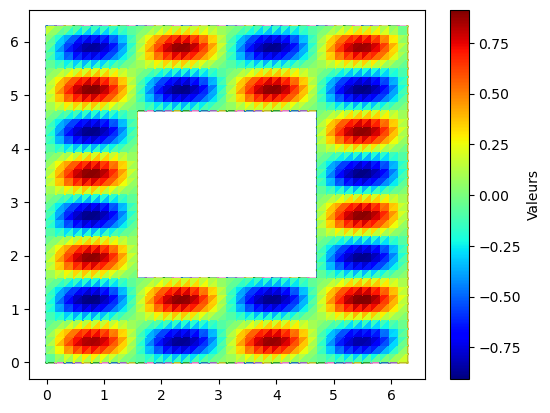

In [233]:
PlotApproximation(Maillage_Filtre_test[1],Maillage_Filtre_test[0],Utest)
#PlotApproximation(K[0],K[1],Utest)

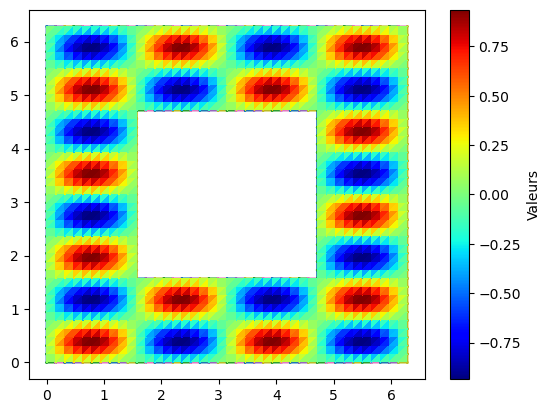

In [234]:
PlotApproximation(np.array(Maillage_Filtre_test[1]),np.array(Maillage_Filtre_test[0]),Interpolation(Maillage_Filtre_test[1],1,2))

In [235]:
def PlotApproximation_erreur(vtx,elt,vh,p,q):
    vh = np.array(vh).flatten()
    I  = Interpolation(vtx,p,q)
    V  = []
    for i in range(0,len(vh)):
        V.append(np.abs(vh[i]-I[i]))
    PlotApproximation(vtx,elt,V)

In [198]:
Utest                = Resolve(41,1,2) 
Maillage_test        = generateMesh(41)
Maillage_Filtre_test = Filtre_(Maillage_test[0],Maillage_test[1])

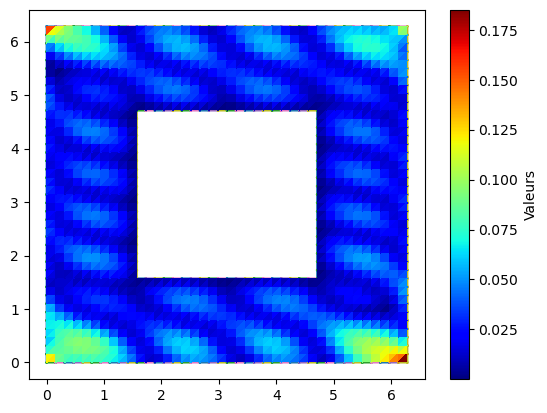

In [199]:
PlotApproximation_erreur(Maillage_Filtre_test[1],Maillage_Filtre_test[0],Utest,1,2)

In [200]:
#question 4

In [212]:
def erreur_L2(vtx,elt,vh,p,q):
    vh = np.array(vh).flatten()
    I  = Interpolation(vtx,p,q)
    
    V  = []
    for i in range(0,len(vh)):
        V.append(I[i]-vh[i])
        
    M       = Mass(vtx, elt)
    l2_vh_I = np.sqrt((V @ M) @ V)
    l2_vh   = np.sqrt((vh @ M) @ vh)
    
    #print(l2_uh)
    return l2_vh_I / l2_vh

#div solution exact

In [213]:
Utest = Resolve(33,1,2)
Maillage_test = generateMesh(33)
Maillage_Filtre_test = Filtre_(Maillage_test[0],Maillage_test[1])
erreur_L2(Maillage_Filtre_test[1],Maillage_Filtre_test[0],Utest,1,2)

0.1305144306042448

0.08133843587275433
Pente estimée : 2.26


<function matplotlib.pyplot.show(close=None, block=None)>

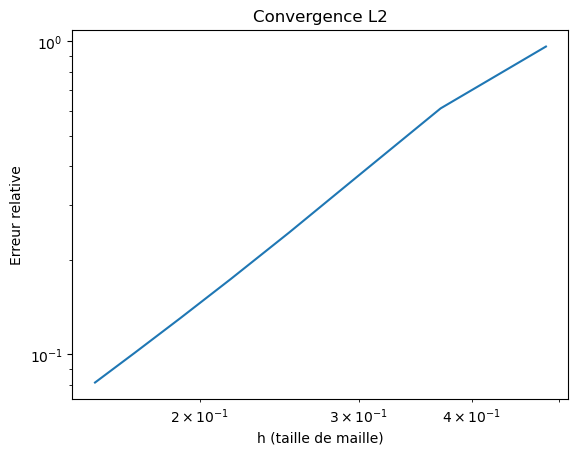

In [223]:
p = 1
q = 2
NN = [4*k + 1 for k in range(3,11)]
#print(NN)
H = [np.pi*2/NN[i] for i in range(0,len(NN))]

Maillage_test = [generateMesh(K) for K in NN]
Maillage_Filtre_test = [Filtre_(e1,e2) for(e1,e2) in Maillage_test]


E = [erreur_L2(Maillage_Filtre_test[i][1],Maillage_Filtre_test[i][0],Resolve(NN[i],p,q),p,q) for i in range(0,len(NN))]
print(E[-1])
plt.loglog(H,E)
plt.xlabel("h (taille de maille)")
plt.ylabel("Erreur relative")
plt.title("Convergence L2")
#plt.loglog(N,E)
log_H = np.log(H)
log_E = np.log(E)
alpha, _ = np.polyfit(log_H[2:], log_E[2:], 1)
print(f"Pente estimée : {alpha:.2f}")
plt.show

In [207]:
def erreur_H1(vtx,elt,vh,p,q):
    vh = np.array(vh).flatten()
    I = Interpolation(vtx,p,q)
    #print('taille vtx =', len(vtx))
    #print(len(vh))
    #print(len(I))
    V = []
    for i in range(0,len(vh)):
        V.append(vh[i]-I[i])
    
    M = Mass(vtx, elt)
    R = Rig(vtx, elt)
    
    l2_vh_I      = np.sqrt((V @ M) @ V)
    grad_l2_vh_I = np.sqrt((V @ R) @ V) 
    H1_vh_I      =  l2_vh_I + grad_l2_vh_I
    
    l2_vh        = np.sqrt((vh @ M) @ vh)
    grad_l2_vh   = np.sqrt((vh @ R) @ vh) 
    H1_vh        = l2_vh + grad_l2_vh
    
    
    #print("||uh||_H1 =", H1_vh)
    #print("||uh - Πhuex||_H1 =", H1_vh_I)
    #print("Relative H1 error =", H1_vh_I / H1_vh)
    #print(l2_uh)
    return H1_vh_I / H1_vh



Pente estimée : 2.12


<function matplotlib.pyplot.show(close=None, block=None)>

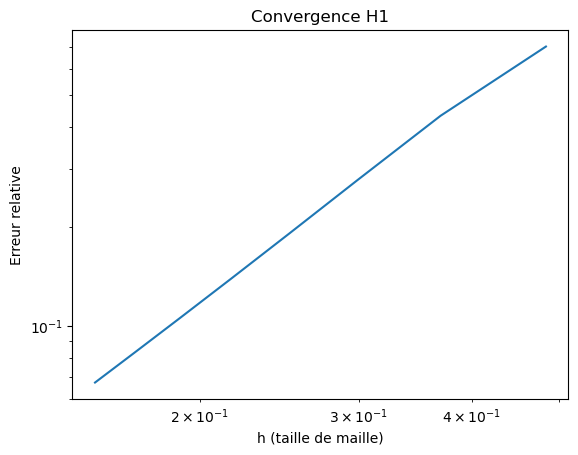

In [221]:
p = 1
q = 2
NN = [4*k + 1 for k in range(3,11)]
#print(NN)
H = [(np.pi*2)/NN[i] for i in range(0,len(NN))]

Maillage_test = [generateMesh(K) for K in NN]
Maillage_Filtre_test = [Filtre_(e1,e2) for (e1,e2) in Maillage_test]


E = [erreur_H1(Maillage_Filtre_test[i][1],Maillage_Filtre_test[i][0],Resolve(NN[i],p,q),p,q) for i in range(0,len(NN))]

plt.loglog(H,E)
plt.xlabel("h (taille de maille)")
plt.ylabel("Erreur relative")
plt.title("Convergence H1")
log_H = np.log(H)
log_E = np.log(E)
alpha, _ = np.polyfit(log_H[2:], log_E[2:], 1)
print(f"Pente estimée : {alpha:.2f}")
plt.show

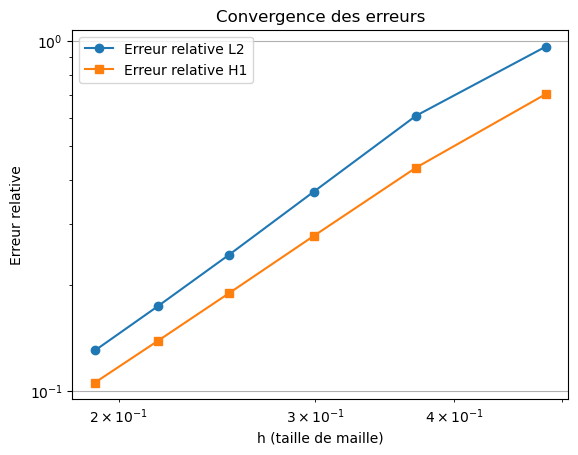

Ordre de convergence estimé (L2)  ≈ 2.19
Ordre de convergence estimé (H1)  ≈ 2.06


In [237]:
p = 1
q = 2
NN = [4*k + 1 for k in range(3, 9)]
#pas lin dependa
H = [2*np.pi / N for N in NN]

E_L2 = []
E_H1 = []

for N in NN:
    # Maillage et filtrage
    vtx, elt = generateMesh(N)
    elt, vtx = Filtre_(vtx, elt)

    # Résolution numérique
    uh = Resolve2(N, p, q)

    # Erreurs
    e_l2 = erreur_L2(vtx, elt, uh, p, q)
    e_h1 = erreur_H1(vtx, elt, uh, p, q)

    E_L2.append(e_l2)
    E_H1.append(e_h1)

# Tracer les erreurs
plt.figure()
plt.loglog(H, E_L2, '-o', label='Erreur relative L2')
plt.loglog(H, E_H1, '-s', label='Erreur relative H1')
plt.xlabel("h (taille de maille)")
plt.ylabel("Erreur relative")
plt.legend()
plt.grid(True)
plt.title("Convergence des erreurs")
plt.show()

# Pentes (ordres de convergence)
logH = np.log(H)
alpha_L2, _ = np.polyfit(logH, np.log(E_L2), 1)
alpha_H1, _ = np.polyfit(logH, np.log(E_H1), 1)

print(f"Ordre de convergence estimé (L2)  ≈ {abs(alpha_L2):.2f}")
print(f"Ordre de convergence estimé (H1)  ≈ {abs(alpha_H1):.2f}")

In [ ]:
# valeurs en croissance logarithmique 